# 📰 AG News Text Classification with TextCNN
---
**Dataset:** AG News (4 classes — World, Sports, Business, Sci/Tech)  
**Model:** TextCNN (Convolutional Neural Network for Text Classification, Kim 2014)  
**Framework:** PyTorch


## Part 1 — Data Preparation for TextCNN


### 1.1 Import Libraries


In [1]:
import os, re, random, warnings, collections, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda


### 1.2 Load Data


In [2]:
train_df = pd.read_csv('/home/thanhf/Pictures/code_otherFolder/CS114/Data/Clean/train_clean.csv')
val_df   = pd.read_csv('/home/thanhf/Pictures/code_otherFolder/CS114/Data/Clean/val_clean.csv')
test_df  = pd.read_csv('/home/thanhf/Pictures/code_otherFolder/CS114/Data/Clean/test_clean.csv')

print(f"Train shape : {train_df.shape}")
print(f"Val shape   : {val_df.shape}")
print(f"Test shape  : {test_df.shape}")


Train shape : (89320, 2)
Val shape   : (12760, 2)
Test shape  : (25520, 2)


### 1.3 Basic Inspection


In [3]:
train_df.head()


,text,label
0,A stinker? Critics pan Spacey 's Old Vic debut...,4
1,quot;Hobbit quot; Joins Human Family A new and...,4
2,Merck stops $2.5 bn painkiller Those taking Vi...,3
3,Six more die in Thai violence BANGKOK: Six mor...,1
4,Virgin launches online music service Virgin Di...,4


In [4]:
print("Label distribution (train):")
print(train_df['label'].value_counts().sort_index())


Label distribution (train):
label
1    22330
2    22330
3    22330
4    22330
Name: count, dtype: int64


### 1.4 Text Preprocessing & Vocabulary Building
We perform simple whitespace tokenisation, build a vocabulary capped at 20 000 words, and reserve indices for `<PAD>` (0) and `<UNK>` (1).


In [5]:
def simple_tokenize(text):
    """Lowercase and split on non-alphanumeric characters."""
    text = str(text).lower()
    return re.findall(r'[a-z0-9]+', text)

# Build vocabulary from training data only
MAX_VOCAB = 50000
PAD_IDX = 0
UNK_IDX = 1

counter = collections.Counter()
for text in train_df['text']:
    counter.update(simple_tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)  # reserve 2 for special tokens
word2idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")


Vocabulary size: 50000


### 1.5 Convert Text to Sequences & Pad


In [6]:
MAX_LEN = 100

def text_to_sequence(text, word2idx, max_len):
    tokens = simple_tokenize(text)[:max_len]
    seq = [word2idx.get(t, UNK_IDX) for t in tokens]
    # Pad
    seq += [PAD_IDX] * (max_len - len(seq))
    return seq

def df_to_tensors(df, word2idx, max_len):
    sequences = [text_to_sequence(t, word2idx, max_len) for t in df['text']]
    X = torch.tensor(sequences, dtype=torch.long)
    # Labels are 1-4 in dataset → convert to 0-3
    y = torch.tensor(df['label'].values - 1, dtype=torch.long)
    return X, y

X_train, y_train = df_to_tensors(train_df, word2idx, MAX_LEN)
X_val,   y_val   = df_to_tensors(val_df,   word2idx, MAX_LEN)
X_test,  y_test  = df_to_tensors(test_df,  word2idx, MAX_LEN)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")


X_train: torch.Size([89320, 100])  y_train: torch.Size([89320])
X_val  : torch.Size([12760, 100])  y_val  : torch.Size([12760])
X_test : torch.Size([25520, 100])  y_test : torch.Size([25520])


### 1.6 Label Mapping


In [7]:
LABEL_NAMES = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
NUM_CLASSES = len(LABEL_NAMES)
print("Label mapping:", LABEL_NAMES)


Label mapping: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


### 1.7 PyTorch Dataset & DataLoader


In [8]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(NewsDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NewsDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(NewsDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches — train: 1396, val: 200, test: 399


---
## Part 2 — Modeling with TextCNN


### 2.1 Hyperparameters


In [9]:
EMBED_DIM    = 128        # Giảm từ 300 → 128 (giảm params đáng kể)
KERNEL_SIZES = [3, 4, 5]
NUM_FILTERS  = 100        # Giảm từ 128 → 100
DROPOUT      = 0.5
EMBED_DROPOUT = 0.3       # Thêm dropout sau embedding
LR           = 1e-3
WEIGHT_DECAY = 1e-3       # Tăng regularization
MAX_EPOCHS   = 50
PATIENCE     = 5          # Tăng patience để không stop quá sớm

### 2.2 TextCNN Architecture
Implementation follows *Convolutional Neural Networks for Sentence Classification* (Yoon Kim, 2014).  
Three parallel Conv1d branches (kernel sizes 3, 4, 5) → global max-pool → concat → FC → softmax.


In [10]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters, kernel_sizes, dropout, embed_dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_dropout = nn.Dropout(embed_dropout)   # ← THÊM dropout sau embedding
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, ks) for ks in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.embed_dropout(x)          # ← THÊM
        x = x.permute(0, 2, 1)
        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            c = F.max_pool1d(c, c.size(2)).squeeze(2)
            conv_outs.append(c)
        x = torch.cat(conv_outs, dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = TextCNN(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES,
                NUM_FILTERS, KERNEL_SIZES, DROPOUT,
                embed_dropout=EMBED_DROPOUT, pad_idx=PAD_IDX).to(DEVICE)

### 2.3 Loss Function & Optimizer


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

### 2.4 Training & Validation Loop with Early Stopping


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * y_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total


In [13]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
best_model_wts = None
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:3d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\n Best validation loss: {best_val_loss:.4f}")


Epoch   1/50 | Train Loss: 0.8063  Acc: 0.6795 | Val Loss: 0.4149  Acc: 0.8613
Epoch   2/50 | Train Loss: 0.4492  Acc: 0.8445 | Val Loss: 0.3427  Acc: 0.8847
Epoch   3/50 | Train Loss: 0.3655  Acc: 0.8767 | Val Loss: 0.3257  Acc: 0.8928
Epoch   4/50 | Train Loss: 0.3202  Acc: 0.8933 | Val Loss: 0.3181  Acc: 0.8950
Epoch   5/50 | Train Loss: 0.2880  Acc: 0.9050 | Val Loss: 0.3037  Acc: 0.8998
Epoch   6/50 | Train Loss: 0.2618  Acc: 0.9135 | Val Loss: 0.3007  Acc: 0.8998
Epoch   7/50 | Train Loss: 0.2431  Acc: 0.9191 | Val Loss: 0.3026  Acc: 0.9003
Epoch   8/50 | Train Loss: 0.2260  Acc: 0.9247 | Val Loss: 0.3058  Acc: 0.9030
Epoch   9/50 | Train Loss: 0.2079  Acc: 0.9304 | Val Loss: 0.3194  Acc: 0.9005
Epoch  10/50 | Train Loss: 0.1792  Acc: 0.9393 | Val Loss: 0.3161  Acc: 0.8999
Epoch  11/50 | Train Loss: 0.1686  Acc: 0.9426 | Val Loss: 0.3196  Acc: 0.9012

⏹ Early stopping at epoch 11 (no improvement for 5 epochs)

 Best validation loss: 0.3007


### 2.5 Final Evaluation on Test Set


In [14]:
# Load best model
model.load_state_dict(best_model_wts)

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.2860
Test Accuracy: 0.9076


In [15]:
# Detailed metrics
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for X_b, y_b in loader:
        logits = model(X_b.to(device))
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(y_b.tolist())
    return all_labels, all_preds

y_true, y_pred = get_predictions(model, test_loader, DEVICE)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(LABEL_NAMES.values())))

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, average='macro'):.4f}")


Classification Report:

              precision    recall  f1-score   support

       World       0.91      0.90      0.90      6380
      Sports       0.96      0.97      0.96      6380
    Business       0.88      0.87      0.87      6380
    Sci/Tech       0.88      0.90      0.89      6380

    accuracy                           0.91     25520
   macro avg       0.91      0.91      0.91     25520
weighted avg       0.91      0.91      0.91     25520

Accuracy : 0.9076
Precision: 0.9075
Recall   : 0.9076
F1-score : 0.9075


### 2.6 Confusion Matrix


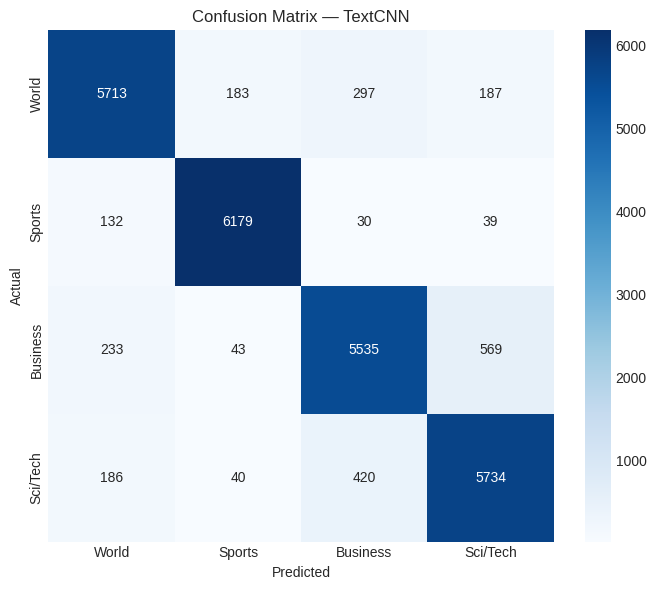

In [16]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(LABEL_NAMES.values()),
            yticklabels=list(LABEL_NAMES.values()), ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — TextCNN')
plt.tight_layout()
plt.show()


### 2.7 Training Curves


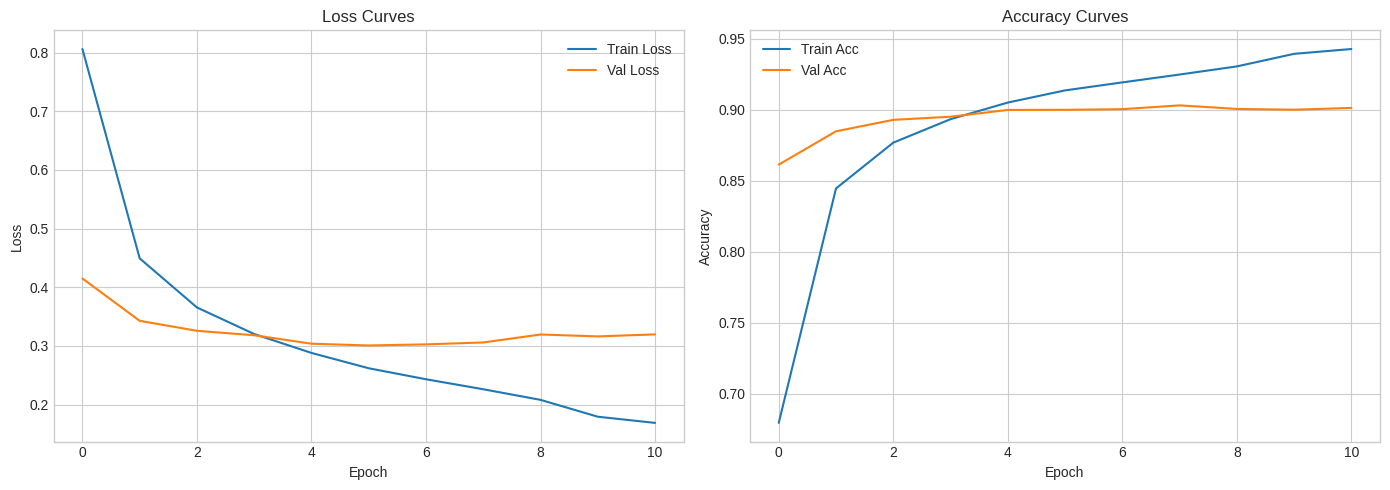

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()

plt.tight_layout()
plt.show()


### 2.8 Save Model


In [18]:
os.makedirs('models', exist_ok=True)
save_path = 'models/textcnn_best.pth'
torch.save(best_model_wts, save_path)
print(f"Model saved to {save_path}")


Model saved to models/textcnn_best.pth


### 2.9 Inference Demo


In [19]:
def predict_text(text, model, word2idx, max_len, device):
    model.eval()
    seq = text_to_sequence(text, word2idx, max_len)
    X = torch.tensor([seq], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(X)
        probs = F.softmax(logits, dim=1)
        pred = logits.argmax(1).item()
    print(f"Text : {text}")
    print(f"Predicted class: {LABEL_NAMES[pred]}")
    print(f"Probabilities  : { {LABEL_NAMES[i]: f'{probs[0,i].item():.4f}' for i in range(NUM_CLASSES)} }")
    return pred

# Example
_ = predict_text("Apple announces a new iPhone with groundbreaking AI features", model, word2idx, MAX_LEN, DEVICE)


Text : Apple announces a new iPhone with groundbreaking AI features
Predicted class: Sci/Tech
Probabilities  : {'World': '0.0094', 'Sports': '0.0061', 'Business': '0.0115', 'Sci/Tech': '0.9730'}


In [20]:
_ = predict_text("Manchester United wins the Champions League final in dramatic fashion", model, word2idx, MAX_LEN, DEVICE)


Text : Manchester United wins the Champions League final in dramatic fashion
Predicted class: Sports
Probabilities  : {'World': '0.0015', 'Sports': '0.9985', 'Business': '0.0000', 'Sci/Tech': '0.0000'}


In [21]:
_ = predict_text("Stock markets plunge amid fears of a global recession", model, word2idx, MAX_LEN, DEVICE)


Text : Stock markets plunge amid fears of a global recession
Predicted class: Business
Probabilities  : {'World': '0.0533', 'Sports': '0.0011', 'Business': '0.8055', 'Sci/Tech': '0.1401'}


---
## Bonus — Pretrained GloVe Embeddings
We compare TextCNN performance **with** and **without** GloVe 6B 100d pretrained embeddings.

> **Note:** Download `glove.6B.100d.txt` from [https://nlp.stanford.edu/data/glove.6B.zip](https://nlp.stanford.edu/data/glove.6B.zip) and place it in the project root (or adjust `GLOVE_PATH`).


In [22]:
GLOVE_PATH = 'glove.6B.100d.txt'
GLOVE_DIM  = 100

def load_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vec
    return embeddings

if os.path.exists(GLOVE_PATH):
    glove = load_glove(GLOVE_PATH)
    print(f"Loaded {len(glove):,} GloVe vectors")

    # Build embedding matrix
    embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
    found = 0
    for word, idx in word2idx.items():
        if word in glove:
            embedding_matrix[idx] = glove[word]
            found += 1
    print(f"Found {found}/{VOCAB_SIZE} words in GloVe ({found/VOCAB_SIZE*100:.1f}%)")

    # New model with GloVe
    model_glove = TextCNN(VOCAB_SIZE, GLOVE_DIM, NUM_CLASSES,
                          NUM_FILTERS, KERNEL_SIZES, DROPOUT, PAD_IDX).to(DEVICE)
    model_glove.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
    model_glove.embedding.weight.requires_grad = True  # fine-tune

    criterion_g = nn.CrossEntropyLoss()
    optimizer_g = torch.optim.AdamW(model_glove.parameters(), lr=LR)

    hist_g = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_vl_g = float('inf')
    best_wts_g = None
    no_imp_g = 0

    for epoch in range(1, MAX_EPOCHS+1):
        tl, ta = train_one_epoch(model_glove, train_loader, criterion_g, optimizer_g, DEVICE)
        vl, va = evaluate(model_glove, val_loader, criterion_g, DEVICE)
        hist_g['train_loss'].append(tl); hist_g['val_loss'].append(vl)
        hist_g['train_acc'].append(ta);  hist_g['val_acc'].append(va)
        print(f"[GloVe] Epoch {epoch:3d} | TrL: {tl:.4f} TrA: {ta:.4f} | VL: {vl:.4f} VA: {va:.4f}")
        if vl < best_vl_g:
            best_vl_g = vl; best_wts_g = copy.deepcopy(model_glove.state_dict()); no_imp_g = 0
        else:
            no_imp_g += 1
            if no_imp_g >= PATIENCE:
                print(f"⏹ Early stopping at epoch {epoch}"); break

    model_glove.load_state_dict(best_wts_g)
    y_true_g, y_pred_g = get_predictions(model_glove, test_loader, DEVICE)
    print("\n--- GloVe TextCNN Test Results ---")
    print(classification_report(y_true_g, y_pred_g, target_names=list(LABEL_NAMES.values())))

    # Comparison
    acc_no  = accuracy_score(y_true, y_pred)
    acc_yes = accuracy_score(y_true_g, y_pred_g)
    print(f"Without GloVe : {acc_no:.4f}")
    print(f"With GloVe    : {acc_yes:.4f}")
    print(f"Difference    : {acc_yes - acc_no:+.4f}")

    torch.save(best_wts_g, 'models/textcnn_glove_best.pth')
    print("GloVe model saved.")
else:
    print(f"GloVe file not found at '{GLOVE_PATH}'. Skipping bonus section.")
    print("Download from: https://nlp.stanford.edu/data/glove.6B.zip")


GloVe file not found at 'glove.6B.100d.txt'. Skipping bonus section.
Download from: https://nlp.stanford.edu/data/glove.6B.zip


### 2.10 Interactive Inference Demo

Enter any news headline or sentence below.  
The model will predict which category it belongs to: **World**, **Sports**, **Business**, or **Sci/Tech**.


In [26]:
# ---------------------------------------------------------------
# Interactive Inference Demo
# ---------------------------------------------------------------
# This cell can run independently after training is complete.
# It reuses: model, best_model_wts, word2idx, LABEL_NAMES,
#            simple_tokenize, MAX_LEN, PAD_IDX, UNK_IDX, DEVICE
# ---------------------------------------------------------------

def interactive_predict(model, word2idx, max_len, device,
                        pad_idx=0, unk_idx=1):
    """
    Interactive inference: reads a sentence from the user via input(),
    preprocesses it through the same pipeline used during training,
    and prints the predicted class index and label name.
    """
    # --- Step 1: Get user input ---
    user_text = input("Enter a news sentence: ")
    if not user_text.strip():
        print("⚠️  Empty input. Please enter a valid sentence.")
        return

    # --- Step 2: Tokenize (same as training) ---
    tokens = simple_tokenize(user_text)

    # --- Step 3: Convert tokens to indices using word2idx ---
    # Unknown words are mapped to <UNK>
    seq = [word2idx.get(tok, unk_idx) for tok in tokens[:max_len]]

    # --- Step 4: Pad / truncate to fixed max_len ---
    seq += [pad_idx] * (max_len - len(seq))

    # --- Step 5: Convert to PyTorch tensor (add batch dim) ---
    x = torch.tensor([seq], dtype=torch.long).to(device)

    # --- Step 6: Run inference (no gradient computation) ---
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = F.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()

    pred_label = LABEL_NAMES[pred_idx]

    # --- Step 7: Display results ---
    print("" + "=" * 50)
    print(f"Input text     : {user_text}")
    print(f"Predicted label: {pred_label}")
    print(f"Class index    : {pred_idx}")
    print("-" * 50)
    print("Class probabilities:")
    for i in range(NUM_CLASSES):
        bar = "█" * int(probs[0, i].item() * 30)
        print(f"  {LABEL_NAMES[i]:10s} : {probs[0, i].item():.4f}  {bar}")
    print("=" * 50)


# --- Load best model weights (saved in Section 2.8) ---
model.load_state_dict(best_model_wts)
print("✅ Best model loaded. Ready for inference.")

# --- Run interactive prediction ---
interactive_predict(model, word2idx, MAX_LEN, DEVICE,
                    pad_idx=PAD_IDX, unk_idx=UNK_IDX)


✅ Best model loaded. Ready for inference.


Input text     : Researchers developed a new AI model capable of detecting early-stage cancer from medical images with high accuracy.
Predicted label: Sci/Tech
Class index    : 3
--------------------------------------------------
Class probabilities:
  World      : 0.1051  ███
  Sports     : 0.0289  
  Business   : 0.0268  
  Sci/Tech   : 0.8393  █████████████████████████


In [ ]:
# VD demo:
# 0. The United Nations announced a new ceasefire agreement between the two countries after weeks of diplomatic negotiations.
# 1. Manchester City secured a dramatic 3-2 victory in the final minutes of the match to remain top of the league table.
# 2. Apple reported stronger-than-expected quarterly revenue driven by increased iPhone sales and growth in services.
# 3. Researchers developed a new AI model capable of detecting early-stage cancer from medical images with high accuracy.

---
**End of Notebook** ✅
